---
### ResNet

In [1]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# 한글 폰트 및 마이너스 기호 표시 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# CUDA 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"현재 디바이스: {device}")

# 재현성을 위한 시드 설정 (선택 사항)
# torch.manual_seed(42)
# np.random.seed(42)
# if device == 'cuda':
#     torch.cuda.manual_seed_all(42)

현재 디바이스: cuda


In [2]:
# CIFAR-100 데이터 로드 함수
def unpickle(file):
    with open(file, 'rb') as fo:
        dict_data = pickle.load(fo, encoding='bytes')
    return dict_data

data_path = './cifar-100-python'
train_path = os.path.join(data_path, 'train')
test_path = os.path.join(data_path, 'test')
meta_path = os.path.join(data_path, 'meta')

# 데이터 로드
train_data_raw = unpickle(train_path)
test_data_raw = unpickle(test_path)
meta_data = unpickle(meta_path)

fine_label_names = [name.decode() for name in meta_data[b'fine_label_names']]
coarse_label_names = [name.decode() for name in meta_data[b'coarse_label_names']]

print("학습 데이터 키:", [key.decode() if isinstance(key, bytes) else key for key in train_data_raw.keys()])
print("테스트 데이터 키:", [key.decode() if isinstance(key, bytes) else key for key in test_data_raw.keys()])

학습 데이터 키: ['filenames', 'batch_label', 'fine_labels', 'coarse_labels', 'data']
테스트 데이터 키: ['filenames', 'batch_label', 'fine_labels', 'coarse_labels', 'data']


In [3]:
# 데이터 추출 및 형태 변경
x_all = train_data_raw[b'data'].reshape(-1, 3, 32, 32).astype(np.float32) / 255.0
# CrossEntropyLoss는 클래스 인덱스를 직접 받으므로 원-핫 인코딩 불필요
y_all_fine = np.array(train_data_raw[b'fine_labels']).astype(np.int64)
# y_all_coarse = np.array(train_data_raw[b'coarse_labels']).astype(np.int64) # 필요시 사용

x_test_final = test_data_raw[b'data'].reshape(-1, 3, 32, 32).astype(np.float32) / 255.0
y_test_final_fine = np.array(test_data_raw[b'fine_labels']).astype(np.int64)
# y_test_final_coarse = np.array(test_data_raw[b'coarse_labels']).astype(np.int64) # 필요시 사용

# 학습/검증 데이터 분할 (fine_labels 기준으로 계층적 샘플링)
x_train, x_val, y_train_fine, y_val_fine = train_test_split(
    x_all, y_all_fine, test_size=0.2, random_state=42, stratify=y_all_fine
)

print(f"x_train shape: {x_train.shape}, y_train_fine shape: {y_train_fine.shape}")
print(f"x_val shape: {x_val.shape}, y_val_fine shape: {y_val_fine.shape}")
print(f"x_test_final shape: {x_test_final.shape}, y_test_final_fine shape: {y_test_final_fine.shape}")

x_train shape: (40000, 3, 32, 32), y_train_fine shape: (40000,)
x_val shape: (10000, 3, 32, 32), y_val_fine shape: (10000,)
x_test_final shape: (10000, 3, 32, 32), y_test_final_fine shape: (10000,)


In [4]:
class CIFAR100Dataset(Dataset):
    def __init__(self, images, labels_fine, transform=None):
        self.images = images  # (N, C, H, W) 형태의 NumPy 배열, 이미 float32로 정규화됨
        self.labels_fine = labels_fine # 클래스 인덱스 형태의 NumPy 배열
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label_fine = self.labels_fine[idx]

        # NumPy 배열을 PyTorch 텐서로 변환
        image_tensor = torch.tensor(image, dtype=torch.float32)
        label_fine_tensor = torch.tensor(label_fine, dtype=torch.long) # CrossEntropyLoss를 위해 long 타입

        if self.transform:
            # torchvision transform은 PIL Image 또는 (C,H,W) 텐서를 기대합니다.
            # 현재 image_tensor는 (C,H,W)이므로 바로 적용 가능
            image_tensor = self.transform(image_tensor)

        return image_tensor, label_fine_tensor

In [5]:
# 데이터 증강 정의 (과적합 방지를 위해 더 많은 기법 추가)
train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15), # 회전 증강
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # 색상 변화
    # transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)) # CIFAR-100 평균/표준편차 (선택사항)
    # Normalize는 데이터 로드 시 이미 /255.0 했으므로, 필요시 평균/표준편차를 다시 계산하여 적용
])

# 검증 및 테스트 데이터에는 일반적으로 Random Augmentation을 적용하지 않음
# (필요시 Normalize만 적용)
val_test_transforms = transforms.Compose([
    # transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)) # 선택사항
])

# Dataset 생성
train_dataset = CIFAR100Dataset(x_train, y_train_fine, transform=train_transforms)
val_dataset = CIFAR100Dataset(x_val, y_val_fine, transform=val_test_transforms) # 검증셋에는 증강 미적용
test_dataset = CIFAR100Dataset(x_test_final, y_test_final_fine, transform=val_test_transforms) # 테스트셋에도 증강 미적용

# DataLoader 생성
BATCH_SIZE = 128 # GPU 메모리에 따라 조절
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train loader: {len(train_loader)} batches")
print(f"Validation loader: {len(val_loader)} batches")
print(f"Test loader: {len(test_loader)} batches")

Train loader: 313 batches
Validation loader: 79 batches
Test loader: 79 batches


In [6]:
# ResNet Basic Block
class BasicBlock(nn.Module):
    expansion = 1 # BasicBlock에서는 expansion factor가 1

    def __init__(self, in_channels, out_channels, stride=1, dropout_rate=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.dropout = nn.Dropout(dropout_rate) if dropout_rate > 0 else None

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        if self.dropout:
            out = self.dropout(out) # Conv 레이어 후 Dropout 추가 가능

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=100, dropout_rate_fc=0.5, dropout_rate_conv=0.0):
        super().__init__()
        self.in_channels = 64
        self.dropout_rate_conv = dropout_rate_conv # Conv 블록 내 드롭아웃 비율

        # 초기 Conv 레이어 (CIFAR 크기에 맞게 조정)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        # self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1) # ImageNet용, CIFAR에서는 제거하거나 stride=1로

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc_dropout = nn.Dropout(dropout_rate_fc) if dropout_rate_fc > 0 else None
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        # 가중치 초기화 (선택 사항)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s, dropout_rate=self.dropout_rate_conv))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        # out = self.maxpool(out) # CIFAR에서는 보통 사용 안 함

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        if self.fc_dropout:
            out = self.fc_dropout(out)
        out = self.fc(out)
        return out

# ResNet18 유사 구조 (CIFAR용으로 블록 수 조정 가능)
def ResNet18_CIFAR(num_classes=100, dropout_rate_fc=0.5, dropout_rate_conv=0.0):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes, dropout_rate_fc, dropout_rate_conv)

# ResNet34 유사 구조
def ResNet34_CIFAR(num_classes=100, dropout_rate_fc=0.5, dropout_rate_conv=0.0):
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes, dropout_rate_fc, dropout_rate_conv)

# 모델 인스턴스 생성
# dropout_rate_conv는 BasicBlock 내부에 적용할 드롭아웃 비율입니다. 0.1~0.2 정도를 시도해볼 수 있습니다.
# dropout_rate_fc는 마지막 FC 레이어 전의 드롭아웃 비율입니다.
# model = ResNet18_CIFAR(num_classes=100, dropout_rate_fc=0.5, dropout_rate_conv=0.1).to(device)
model = ResNet34_CIFAR(num_classes=100, dropout_rate_fc=0.5, dropout_rate_conv=0.1).to(device) # 더 깊은 모델

print(model)
# 모델 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"총 학습 가능한 파라미터 수: {total_params:,}")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2

In [11]:
# 손실 함수 (Label Smoothing 적용 가능)
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, classes, smoothing=0.1, dim=-1):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.cls = classes
        self.dim = dim

    def forward(self, pred, target):
        pred = pred.log_softmax(dim=self.dim)
        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (self.cls - 1))
            true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        return torch.mean(torch.sum(-true_dist * pred, dim=self.dim))

LEARNING_RATE = 1e-3 # 0.001
WEIGHT_DECAY = 1e-4 # L2 정규화 (가중치 감쇠)
SMOOTHING = 0.1 # Label smoothing 강도
NUM_EPOCHS = 200 # 총 학습 에폭 수

# criterion = nn.CrossEntropyLoss() # 기본 CrossEntropyLoss
criterion = LabelSmoothingCrossEntropy(classes=100, smoothing=SMOOTHING).to(device)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# 학습률 스케줄러
# ReduceLROnPlateau: 검증 손실이 정체될 때 학습률 감소
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)
# StepLR: 특정 에폭마다 학습률 감소
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
# CosineAnnealingLR: 코사인 함수 형태로 학습률 변화
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print(f"Optimizer: Adam, LR: {LEARNING_RATE}, Weight Decay: {WEIGHT_DECAY}")
print(f"Criterion: LabelSmoothingCrossEntropy (smoothing={SMOOTHING})")
print(f"Scheduler: ReduceLROnPlateau")

Optimizer: Adam, LR: 0.001, Weight Decay: 0.0001
Criterion: LabelSmoothingCrossEntropy (smoothing=0.1)
Scheduler: ReduceLROnPlateau


In [12]:
NUM_EPOCHS = 200 # 총 에폭 수
EARLY_STOPPING_PATIENCE = 20 # 검증 손실이 이 횟수만큼 개선되지 않으면 조기 종료
best_val_loss = float('inf')
epochs_no_improve = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print(f"Training for {NUM_EPOCHS} epochs with Early Stopping (patience={EARLY_STOPPING_PATIENCE})...")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()
    # --- 학습 단계 ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    # tqdm으로 진행 상황 표시
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False)
    for images, labels_fine in train_pbar:
        images, labels_fine = images.to(device), labels_fine.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_fine)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels_fine.size(0)
        correct_train += (predicted == labels_fine).sum().item()
        train_pbar.set_postfix({'loss': loss.item(), 'acc': (predicted == labels_fine).sum().item() / images.size(0)})

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = 100 * correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    # --- 검증 단계 ---
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]", leave=False)
    with torch.no_grad():
        for images, labels_fine in val_pbar:
            images, labels_fine = images.to(device), labels_fine.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels_fine) # 검증 시에도 동일한 손실 함수 사용

            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels_fine.size(0)
            correct_val += (predicted == labels_fine).sum().item()
            val_pbar.set_postfix({'loss': loss.item(), 'acc': (predicted == labels_fine).sum().item() / images.size(0)})

    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = 100 * correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    end_time = time.time()
    epoch_duration = end_time - start_time

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] ({epoch_duration:.2f}s) - "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}% | "
          f"LR: {optimizer.param_groups[0]['lr']:.1e}")

    # 학습률 스케줄러 업데이트 (ReduceLROnPlateau는 val_loss를 인자로 받음)
    if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(epoch_val_loss)
    else:
        scheduler.step() # StepLR, CosineAnnealingLR 등

    # 조기 종료 확인
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        # 최고 성능 모델 저장 (선택 사항)
        torch.save(model.state_dict(), 'best_resnet_cifar100_model.pth')
        print(f"Validation loss improved to {best_val_loss:.4f}. Saving model...")
    else:
        epochs_no_improve += 1
        print(f"Validation loss did not improve for {epochs_no_improve} epoch(s).")

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping triggered after {epoch+1} epochs as validation loss did not improve for {EARLY_STOPPING_PATIENCE} epochs.")
        break
print("학습 완료!")

Training for 200 epochs with Early Stopping (patience=20)...


Epoch [1/200] (90.22s) - Train Loss: 1.5479, Train Acc: 76.91% | Val Loss: 1.9064, Val Acc: 66.20% | LR: 1.0e-03
Validation loss improved to 1.9064. Saving model...


Epoch [2/200] (89.15s) - Train Loss: 1.5447, Train Acc: 77.18% | Val Loss: 1.9236, Val Acc: 65.53% | LR: 1.0e-03
Validation loss did not improve for 1 epoch(s).


Epoch [3/200] (88.76s) - Train Loss: 1.5471, Train Acc: 76.89% | Val Loss: 1.9115, Val Acc: 66.12% | LR: 1.0e-03
Validation loss did not improve for 2 epoch(s).


Epoch [4/200] (88.83s) - Train Loss: 1.5470, Train Acc: 76.61% | Val Loss: 1.9316, Val Acc: 65.03% | LR: 1.0e-03
Validation loss did not improve for 3 epoch(s).


...

Epoch [39/200] (109.08s) - Train Loss: 1.0654, Train Acc: 93.51% | Val Loss: 1.7228, Val Acc: 72.58% | LR: 1.0e-05
Validation loss did not improve for 16 epoch(s).


Epoch [40/200] (108.74s) - Train Loss: 1.0603, Train Acc: 93.83% | Val Loss: 1.7250, Val Acc: 72.51% | LR: 1.0e-05
Validation loss did not improve for 17 epoch(s).


Epoch [41/200] (108.58s) - Train Loss: 1.0595, Train Acc: 93.81% | Val Loss: 1.7209, Val Acc: 72.57% | LR: 1.0e-05
Validation loss did not improve for 18 epoch(s).


Epoch [42/200] (108.01s) - Train Loss: 1.0603, Train Acc: 93.63% | Val Loss: 1.7225, Val Acc: 72.45% | LR: 1.0e-05
Validation loss did not improve for 19 epoch(s).


Epoch [43/200] (90.87s) - Train Loss: 1.0550, Train Acc: 94.00% | Val Loss: 1.7263, Val Acc: 72.41% | LR: 1.0e-05
Validation loss did not improve for 20 epoch(s).
Early stopping triggered after 43 epochs as validation loss did not improve for 20 epochs.
학습 완료!


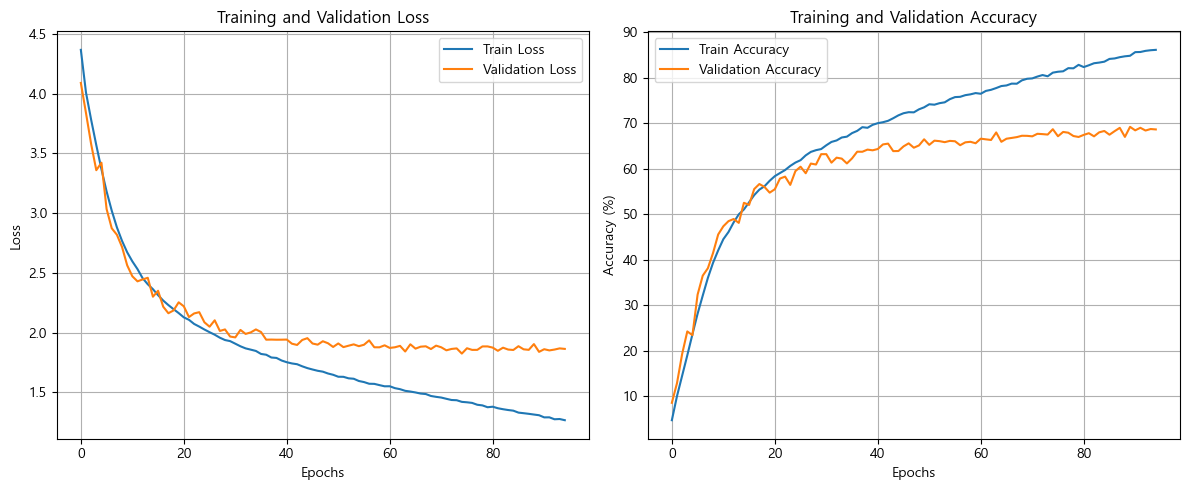

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# 가장 성능이 좋았던 모델 로드 (조기 종료 시 저장된 모델)
if os.path.exists('best_resnet_cifar100_model.pth'):
    print("Loading best model for testing...")
    model.load_state_dict(torch.load('best_resnet_cifar100_model.pth', map_location=device))
else:
    print("Best model not found. Testing with the last model.")

model.eval()
test_loss = 0.0
correct_test = 0
total_test = 0

test_pbar = tqdm(test_loader, desc="[Test]", leave=False)
with torch.no_grad():
    for images, labels_fine in test_pbar:
        images, labels_fine = images.to(device), labels_fine.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels_fine) # 테스트 시에도 동일한 손실 함수 사용

        test_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_test += labels_fine.size(0)
        correct_test += (predicted == labels_fine).sum().item()
        test_pbar.set_postfix({'loss': loss.item(), 'acc': (predicted == labels_fine).sum().item() / images.size(0)})

final_test_loss = test_loss / total_test
final_test_acc = 100 * correct_test / total_test

print(f"\n--- 최종 테스트 결과 ---")
print(f"Test Loss: {final_test_loss:.4f}")
print(f"Test Accuracy on {total_test} test images: {final_test_acc:.2f}%")

Loading best model for testing...



--- 최종 테스트 결과 ---
Test Loss: 1.8418
Test Accuracy on 10000 test images: 67.93%
